In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_sample_submission.csv
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_detailed_class_info.csv
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/GCP Credits Request Link - RSNA.txt
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_labels.csv
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images/c3b05294-29be-46e4-8a51-96fd211e4ca5.dcm
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images/6a6ed2c5-d179-4c19-aac7-0d70eb87e024.dcm
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images/06550cfd-e9d5-415e-bae9-3146329ed9e6.dcm
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images/ef9eee29-6bdd-41da-ae40-9473592a9d5c.dcm
/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images/c5dfc1a7-4669-42ce-af9f-62c3d8322049.dcm
/kaggle/i

In [2]:
# %% [CELDA 1] -- Imports
import os
import time
import json
import numpy as np
import pandas as pd
import pydicom
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
 
INPUT_DIR = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"
TRAIN_IMG_DIR = os.path.join(INPUT_DIR, "stage_2_train_images")
 
IMG_SIZE = 512  # decidido en el EDA
SEED = 42
torch.manual_seed(SEED)
 
# --- Control de presupuesto de tiempo para correr sin supervisión ---
# Pensado para "Save & Run All (Commit)": el notebook corre completo, sin
# nadie mirando, y Kaggle corta todo a las 12h sin avisar a mitad de un
# guardado. Este presupuesto deja margen para que CADA FASE se detenga
# sola, de forma segura (guardando lo que tenga), antes de llegar a ese
# límite duro.
SESSION_START_TIME = time.time()
MAX_SESSION_HOURS = 11.0  # margen de 1h bajo el límite duro de 12h de Kaggle
 
def horas_transcurridas():
    return (time.time() - SESSION_START_TIME) / 3600
 
def tiempo_agotado(margen_horas=0.5):
    return horas_transcurridas() > (MAX_SESSION_HOURS - margen_horas)
 

CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
 
def guardar_estado_entrenamiento(nombre, epoch, extra=None):
    path = os.path.join(CHECKPOINT_DIR, f"estado_{nombre}.json")
    data = {"ultima_epoch_completada": epoch, "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")}
    if extra:
        data.update(extra)
    with open(path, "w") as f:
        json.dump(data, f, indent=2)
 
def cargar_estado_entrenamiento(nombre):
    path = os.path.join(CHECKPOINT_DIR, f"estado_{nombre}.json")
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None
np.random.seed(SEED)

Device: cuda


In [3]:
# %% [CELDA 2] -- Cargar labels y armar tabla a nivel paciente (no a nivel bbox)
train_labels = pd.read_csv(os.path.join(INPUT_DIR, "stage_2_train_labels.csv"))
 
# Para clasificación, solo nos importa patientId + Target (1 fila por paciente)
patient_df = train_labels.drop_duplicates("patientId")[["patientId", "Target"]].reset_index(drop=True)
print(patient_df.shape)
print(patient_df["Target"].value_counts(normalize=True))

(26684, 2)
Target
0    0.774696
1    0.225304
Name: proportion, dtype: float64


In [4]:
# %% [CELDA 3] -- Split train / validation (estratificado por Target)
train_df, val_df = train_test_split(
    patient_df,
    test_size=0.15,
    stratify=patient_df["Target"],
    random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
 
print(f"Train: {len(train_df)} | Val: {len(val_df)}")
print("Train Target dist:", train_df["Target"].value_counts(normalize=True).to_dict())
print("Val Target dist:", val_df["Target"].value_counts(normalize=True).to_dict())

Train: 22681 | Val: 4003
Train Target dist: {0: 0.7747012918301662, 1: 0.22529870816983377}
Val Target dist: {0: 0.7746689982513115, 1: 0.22533100174868848}


In [5]:
# %% [CELDA 4] -- Dataset de PyTorch para clasificación
class RSNAClassificationDataset(Dataset):
    def __init__(self, df, img_dir, img_size=512, augment=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.img_size = img_size
        self.augment = augment
 
    def __len__(self):
        return len(self.df)
 
    def _load_image(self, patient_id):
        path = os.path.join(self.img_dir, f"{patient_id}.dcm")
        dcm = pydicom.dcmread(path)
        img = dcm.pixel_array.astype(np.float32)
        # Normalizar a 0-1
        img = (img - img.min()) / (img.max() - img.min() + 1e-7)
        img = cv2.resize(img, (self.img_size, self.img_size))
        return img
 
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_image(row["patientId"])
 
        if self.augment:
            # Augmentations simples y seguras para radiografías
            # (NO usar flips verticales: invertirían arriba/abajo del tórax)
            if np.random.rand() < 0.5:
                img = np.fliplr(img).copy()  # flip horizontal sí es razonable
            if np.random.rand() < 0.3:
                brightness = np.random.uniform(0.9, 1.1)
                img = np.clip(img * brightness, 0, 1)
 
        # 1 canal -> tensor (1, H, W)
        img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(row["Target"], dtype=torch.float32)
        return img_tensor, label
 
 
train_dataset = RSNAClassificationDataset(train_df, TRAIN_IMG_DIR, IMG_SIZE, augment=True)
val_dataset = RSNAClassificationDataset(val_df, TRAIN_IMG_DIR, IMG_SIZE, augment=False)
 
# Prueba rápida: ver que un batch se carga bien
img_t, label_t = train_dataset[0]
print(img_t.shape, img_t.min().item(), img_t.max().item(), label_t)

torch.Size([1, 512, 512]) 0.0 0.9573991298675537 tensor(0.)


In [6]:
# %% [CELDA 5] -- DataLoaders
BATCH_SIZE = 64  # ResNet18 es ligero;
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True, persistent_workers=True)
 
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


Train batches: 355 | Val batches: 63


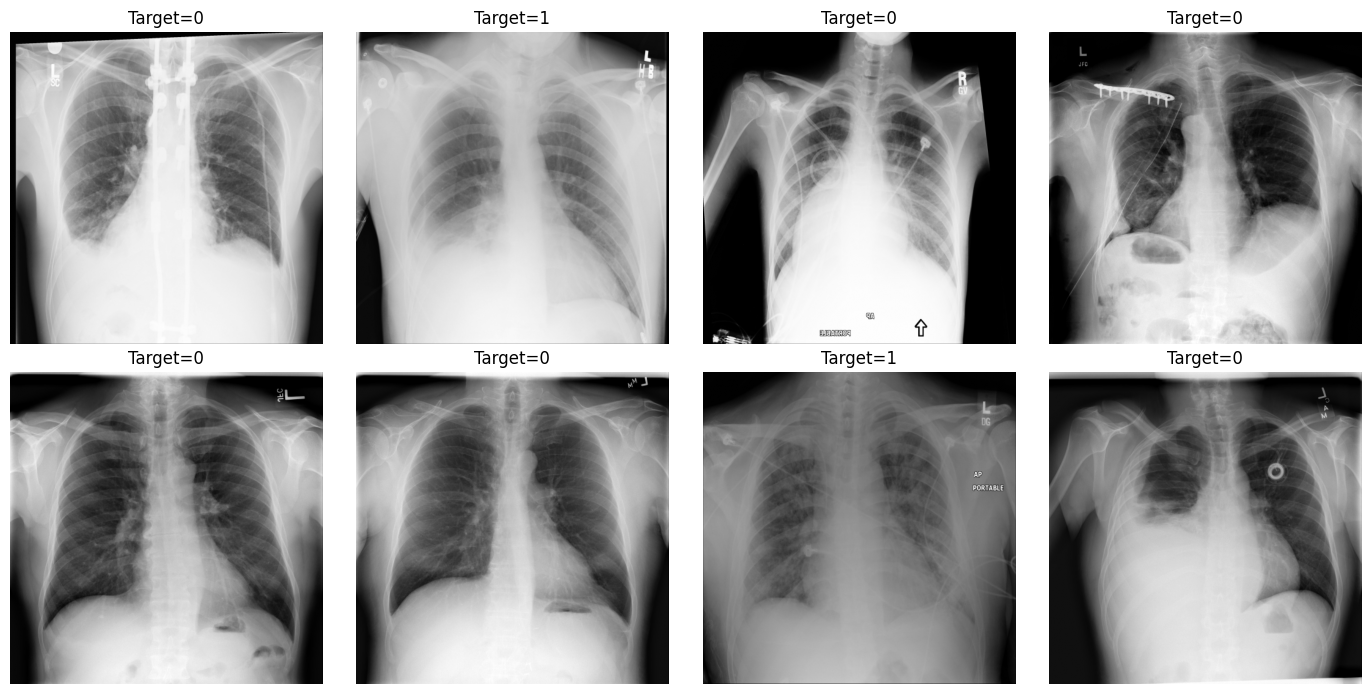

In [7]:
# %% [CELDA 6] -- Visualizar un batch para confirmar que todo está bien
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i, 0].numpy(), cmap="gray")
    ax.set_title(f"Target={int(labels[i].item())}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [8]:
# %% [CELDA 7] -- Modelo: ResNet18 adaptado a 1 canal (grayscale)
def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
 
    # Adaptar la primera capa conv de 3 canales -> 1 canal
    # Promediamos los pesos RGB preentrenados en lugar de reinicializar random
    old_conv = model.conv1
    new_conv = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size,
                          stride=old_conv.stride, padding=old_conv.padding, bias=False)
    with torch.no_grad():
        new_conv.weight = nn.Parameter(old_conv.weight.mean(dim=1, keepdim=True))
    model.conv1 = new_conv
 
    # Cabeza de salida: 1 logit (clasificación binaria con BCEWithLogitsLoss)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model
 
model = build_model().to(device)
 
# DataParallel SÍ es seguro aquí (a diferencia de RetinaNet en la Fase B):
# este modelo recibe un tensor homogéneo (B, 1, H, W) y devuelve un tensor
# (B, 1) -- exactamente lo que DataParallel sabe partir entre GPUs sin
# necesitar lógica manual. Reparte el batch automáticamente.
if torch.cuda.device_count() >= 2:
    print(f"Usando {torch.cuda.device_count()} GPUs con DataParallel")
    model = nn.DataParallel(model)
 
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


Usando 2 GPUs con DataParallel
DataParallel(
  (module): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, m

In [9]:
# %% [CELDA 8] -- Loss, optimizer y scheduler
# Dataset desbalanceado (~77.5% / 22.5%) -> pos_weight en la loss para
# que los positivos (minoría) pesen más y no se ignoren
n_neg = (train_df["Target"] == 0).sum()
n_pos = (train_df["Target"] == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f"pos_weight calculado: {pos_weight.item():.3f}")
 
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                        factor=0.5, patience=2)
 
# AMP es seguro aquí: BCEWithLogitsLoss no tiene la inestabilidad numérica
# que sí tiene el Focal Loss de RetinaNet en fp16 (visto en la Fase B).
scaler = torch.amp.GradScaler("cuda")

pos_weight calculado: 3.439


In [10]:
# %% [CELDA 9] -- Funciones de entrenamiento y evaluación
import time
 
LOG_PATH_A = "/kaggle/working/progreso_fase_a.txt"
 
def log_to_file(path, message):
    timestamp = time.strftime("%Y-%m-%d %H:%M:%S")
    with open(path, "a") as f:
        f.write(f"[{timestamp}] {message}\n")
 
 
def train_one_epoch(model, loader, criterion, optimizer, device, scaler, log_every=20):
    model.train()
    running_loss = 0.0
    t_start = time.time()
    n_total = len(loader)
 
    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True).unsqueeze(1)
 
        optimizer.zero_grad()
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
 
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
 
        running_loss += loss.item() * imgs.size(0)
 
        if (batch_idx + 1) % log_every == 0 or (batch_idx + 1) == n_total:
            elapsed = time.time() - t_start
            msg = f"  batch {batch_idx+1}/{n_total} | loss={loss.item():.4f} | {elapsed:.0f}s"
            print(msg)
            log_to_file(LOG_PATH_A, msg)
 
    return running_loss / len(loader.dataset)
 
 
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels, all_probs = [], []
 
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
 
            probs = torch.sigmoid(outputs.float()).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy().flatten())
 
    val_loss = running_loss / len(loader.dataset)
    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, np.array(all_probs) > 0.5)
    return val_loss, auc, acc, np.array(all_labels), np.array(all_probs)
 

In [11]:
# %% [CELDA 10] -- Loop de entrenamiento principal (con reanudación y control de tiempo)
N_EPOCHS = 10  # ajustar según tiempo disponible (Kaggle GPU tiene límite de horas/semana)
best_auc = 0.0
history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_acc": []}
LAST_CKPT_PATH = os.path.join(CHECKPOINT_DIR, "fase_a_last.pth")
HISTORY_PATH = os.path.join(CHECKPOINT_DIR, "fase_a_history.json")
 
def get_state_dict(m):
    return m.module.state_dict() if isinstance(m, nn.DataParallel) else m.state_dict()
 
def set_state_dict(m, state_dict):
    if isinstance(m, nn.DataParallel):
        m.module.load_state_dict(state_dict)
    else:
        m.load_state_dict(state_dict)
 

start_epoch = 0
estado_previo = cargar_estado_entrenamiento("fase_a")
if estado_previo is not None and os.path.exists(LAST_CKPT_PATH):
    ckpt = torch.load(LAST_CKPT_PATH, map_location=device)
    set_state_dict(model, ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scaler.load_state_dict(ckpt["scaler_state"])
    best_auc = ckpt.get("best_auc", 0.0)
    if os.path.exists(HISTORY_PATH):
        with open(HISTORY_PATH) as f:
            history = json.load(f)
    start_epoch = estado_previo["ultima_epoch_completada"] + 1
    msg = f"Reanudando Fase A desde época {start_epoch} (best_auc previo={best_auc:.4f})"
    print(msg)
    log_to_file(LOG_PATH_A, msg)
else:
    log_to_file(LOG_PATH_A, f"=== Nueva corrida Fase A -- {N_EPOCHS} épocas, batch_size={BATCH_SIZE} ===")
    print(f"Log de progreso en: {LOG_PATH_A}")
 
fase_a_completa = start_epoch >= N_EPOCHS
 
for epoch in range(start_epoch, N_EPOCHS):
    
    if tiempo_agotado(margen_horas=0.5):
        msg = (f"⏱️ Presupuesto de tiempo agotado ({horas_transcurridas():.1f}h transcurridas) "
               f"-- deteniendo Fase A en época {epoch} de forma segura.")
        print(msg)
        log_to_file(LOG_PATH_A, msg)
        break
 
    try:
        epoch_start = time.time()
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler)
        val_loss, val_auc, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        epoch_elapsed = time.time() - epoch_start
 
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)
        history["val_acc"].append(val_acc)
 
        epoch_msg = (f"Epoch {epoch+1}/{N_EPOCHS} | "
                     f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
                     f"val_AUC={val_auc:.4f} | val_acc={val_acc:.4f} | "
                     f"duración={epoch_elapsed:.0f}s | sesión={horas_transcurridas():.2f}h")
        print(epoch_msg)
        log_to_file(LOG_PATH_A, epoch_msg)
 
        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(get_state_dict(model), "best_classifier.pth")
            save_msg = f"  -> Nuevo mejor modelo guardado (AUC={best_auc:.4f})"
            print(save_msg)
            log_to_file(LOG_PATH_A, save_msg)
 
        # Checkpoint de "última época" en CADA época (no solo la mejor),
        # con todo lo necesario para reanudar exactamente desde aquí:
        # pesos del modelo, estado del optimizer y del scaler de AMP.
        torch.save({
            "model_state": get_state_dict(model),
            "optimizer_state": optimizer.state_dict(),
            "scaler_state": scaler.state_dict(),
            "best_auc": best_auc,
        }, LAST_CKPT_PATH)
        with open(HISTORY_PATH, "w") as f:
            json.dump(history, f)
        guardar_estado_entrenamiento("fase_a", epoch, extra={"best_auc": best_auc})
 
        if epoch == N_EPOCHS - 1:
            fase_a_completa = True
 
    except Exception as e:
        # En modo "Save & Run All" sin supervisión, un error sin capturar
        # aquí tumbaría TODO el commit (incluyendo la Fase B que vendría
        # después). Mejor registrar el error y detener solo esta fase.
        err_msg = f"❌ ERROR en época {epoch+1} de Fase A: {type(e).__name__}: {e}"
        print(err_msg)
        log_to_file(LOG_PATH_A, err_msg)
        break
 
print(f"\nFase A {'COMPLETA' if fase_a_completa else 'DETENIDA (parcial)'} | "
      f"best_auc={best_auc:.4f} | tiempo de sesión usado: {horas_transcurridas():.2f}h")
 

Log de progreso en: /kaggle/working/progreso_fase_a.txt
  batch 20/355 | loss=0.7852 | 10s
  batch 40/355 | loss=0.8392 | 17s
  batch 60/355 | loss=0.7365 | 24s
  batch 80/355 | loss=0.7726 | 31s
  batch 100/355 | loss=0.5430 | 38s
  batch 120/355 | loss=0.6939 | 45s
  batch 140/355 | loss=0.8989 | 52s
  batch 160/355 | loss=0.6968 | 59s
  batch 180/355 | loss=0.7627 | 66s
  batch 200/355 | loss=1.0381 | 73s
  batch 220/355 | loss=0.5736 | 80s
  batch 240/355 | loss=0.6996 | 87s
  batch 260/355 | loss=0.8188 | 94s
  batch 280/355 | loss=0.7046 | 100s
  batch 300/355 | loss=0.6752 | 107s
  batch 320/355 | loss=0.9937 | 114s
  batch 340/355 | loss=0.6808 | 121s
  batch 355/355 | loss=0.4541 | 127s
Epoch 1/10 | train_loss=0.7447 | val_loss=0.7223 | val_AUC=0.8632 | val_acc=0.7974 | duración=148s | sesión=0.04h
  -> Nuevo mejor modelo guardado (AUC=0.8632)
  batch 20/355 | loss=0.7618 | 8s
  batch 40/355 | loss=0.5889 | 14s
  batch 60/355 | loss=0.6000 | 21s
  batch 80/355 | loss=0.7073 | 

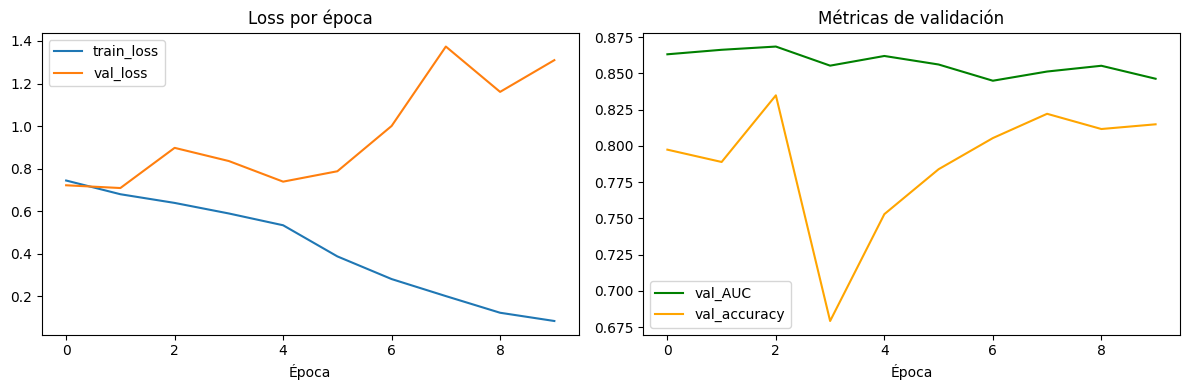

In [12]:
# %% [CELDA 11] -- Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].plot(history["train_loss"], label="train_loss")
axes[0].plot(history["val_loss"], label="val_loss")
axes[0].set_title("Loss por época")
axes[0].set_xlabel("Época")
axes[0].legend()
 
axes[1].plot(history["val_auc"], label="val_AUC", color="green")
axes[1].plot(history["val_acc"], label="val_accuracy", color="orange")
axes[1].set_title("Métricas de validación")
axes[1].set_xlabel("Época")
axes[1].legend()
 
plt.tight_layout()
plt.show()
 

AUC final: 0.8685

Matriz de confusión (umbral=0.5):
[[2873  228]
 [ 433  469]]
Sensibilidad (recall positivos): 0.520
Especificidad (recall negativos): 0.926

Umbral óptimo (Youden's J): 0.211


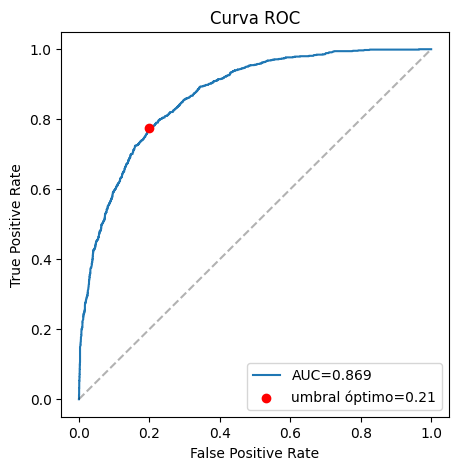

In [13]:
# %% [CELDA 12] -- Análisis del mejor modelo: matriz de confusión y umbral óptimo
set_state_dict(model, torch.load("best_classifier.pth"))
val_loss, val_auc, val_acc, y_true, y_probs = evaluate(model, val_loader, criterion, device)
 
print(f"AUC final: {val_auc:.4f}")
 
# Matriz de confusión con umbral 0.5
cm = confusion_matrix(y_true, y_probs > 0.5)
print("\nMatriz de confusión (umbral=0.5):")
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f"Sensibilidad (recall positivos): {tp/(tp+fn):.3f}")
print(f"Especificidad (recall negativos): {tn/(tn+fp):.3f}")
 
# Buscar umbral que maximiza (sensibilidad + especificidad) -> útil más adelante
# para decidir el corte de confianza en las predicciones de detección
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"\nUmbral óptimo (Youden's J): {optimal_threshold:.3f}")
 
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC={val_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.3)
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color="red", zorder=5,
            label=f"umbral óptimo={optimal_threshold:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

In [14]:
# %% [CELDA 13] -- Conclusiones de la Fase A (clasificación)
"""
CHECKLIST antes de pasar a la Fase B (detección con RetinaNet):

[si] ¿El pipeline de carga DICOM -> tensor funciona sin errores?
[si] ¿El AUC de validación es razonablemente alto (>0.80 ya es decente para
    un baseline simple sin mucho tuning)?
[si] ¿La matriz de confusión muestra que el modelo distingue algo,
    no solo predice la clase mayoritaria?
[ ] ¿El pos_weight ayudó vs. no usarlo? (puedes comparar quitándolo)

Esta Fase A NO te da score directo en la competencia (la competencia pide
bounding boxes, no solo clasificación binaria), pero te confirma que:
- La lectura de datos es correcta
- El split train/val es razonable
- El modelo aprende señal real de la imagen (no ruido)

Con esto validado, pasamos a la Fase B donde SÍ generamos bounding boxes
con RetinaNet, reutilizando este mismo patrón de Dataset/DataLoader.
"""

'\nCHECKLIST antes de pasar a la Fase B (detección con RetinaNet):\n\n[si] ¿El pipeline de carga DICOM -> tensor funciona sin errores?\n[si] ¿El AUC de validación es razonablemente alto (>0.80 ya es decente para\n    un baseline simple sin mucho tuning)?\n[si] ¿La matriz de confusión muestra que el modelo distingue algo,\n    no solo predice la clase mayoritaria?\n[ ] ¿El pos_weight ayudó vs. no usarlo? (puedes comparar quitándolo)\n\nEsta Fase A NO te da score directo en la competencia (la competencia pide\nbounding boxes, no solo clasificación binaria), pero te confirma que:\n- La lectura de datos es correcta\n- El split train/val es razonable\n- El modelo aprende señal real de la imagen (no ruido)\n\nCon esto validado, pasamos a la Fase B donde SÍ generamos bounding boxes\ncon RetinaNet, reutilizando este mismo patrón de Dataset/DataLoader.\n'

identificacion box

In [15]:
# =============================================================================
# RSNA Pneumonia Detection Challenge - BASELINE FASE B: Detección (RetinaNet)
# Continúa en el MISMO notebook después de la Fase A.
# Objetivo: generar bounding boxes reales y un submission.csv válido.
# =============================================================================
 
# %% [CELDA 14] -- Imports adicionales para detección
import torchvision
from torchvision.models.detection import retinanet_resnet50_fpn_v2
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchvision.ops import box_convert
from functools import partial
import matplotlib.patches as patches  # necesario para dibujar bounding boxes
 
print(torchvision.__version__)

0.25.0+cu128


In [16]:
#%% [CELDA 15] -- Re-armar la tabla a nivel de BBOX (ahora sí necesitamos cada caja)
# A diferencia de la Fase A, aquí SÍ nos importa cada fila de train_labels
train_labels = pd.read_csv(os.path.join(INPUT_DIR, "stage_2_train_labels.csv"))
 
# Agrupar cajas por paciente: lista de [x, y, w, h] por patientId
def get_boxes_for_patient(patient_id, df):
    rows = df[df["patientId"] == patient_id]
    if rows["Target"].iloc[0] == 0:
        return []
    boxes = rows[["x", "y", "width", "height"]].values.tolist()
    return boxes  # lista de [x, y, w, h], puede tener 0, 1 o más cajas
 
# Split a nivel paciente (reutilizamos train_df/val_df de la Fase A para
# mantener consistencia, pero si corres esto de forma independiente,
# vuelve a generarlos con train_test_split como en la Celda 3 de Fase A)
 

In [17]:
# %% [CELDA 16] -- Dataset de detección (formato esperado por torchvision)
class RSNADetectionDataset(Dataset):
    """
    torchvision espera que cada __getitem__ devuelva:
      - image: tensor (C, H, W) normalizado a 1 canal
      - target: dict con:
          'boxes': tensor (N, 4) en formato [x1, y1, x2, y2]
          'labels': tensor (N,) -- aquí todo es clase 1 ("opacidad")
          'image_id': tensor escalar
    """
    def __init__(self, df, img_dir, label_df, img_size=512, augment=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.label_df = label_df
        self.img_size = img_size
        self.augment = augment
        self.orig_size = 1024  # tamaño original de las radiografías
 
    def __len__(self):
        return len(self.df)
 
    def _load_image(self, patient_id):
        path = os.path.join(self.img_dir, f"{patient_id}.dcm")
        dcm = pydicom.dcmread(path)
        img = dcm.pixel_array.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-7)
        img = cv2.resize(img, (self.img_size, self.img_size))
        return img
 
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patient_id = row["patientId"]
        img = self._load_image(patient_id)
 
        boxes_raw = get_boxes_for_patient(patient_id, self.label_df)  # en escala 1024
        scale = self.img_size / self.orig_size
 
        boxes = []
        for x, y, w, h in boxes_raw:
            x1, y1 = x * scale, y * scale
            x2, y2 = (x + w) * scale, (y + h) * scale
            boxes.append([x1, y1, x2, y2])
 
        # Flip horizontal como augmentation (ajustando las cajas también)
        # Una sola decisión de flip (evita llamar np.random.rand() dos veces
        # con resultados distintos, que es lo que rompía el flujo antes)
        do_flip = self.augment and (np.random.rand() < 0.5)
 
        if do_flip:
            img = np.fliplr(img).copy()
            if len(boxes) > 0:
                new_boxes = []
                for x1, y1, x2, y2 in boxes:
                    new_x1 = self.img_size - x2
                    new_x2 = self.img_size - x1
                    new_boxes.append([new_x1, y1, new_x2, y2])
                boxes = new_boxes
            # si len(boxes) == 0, no hay nada que transformar, solo la imagen
 
        img_tensor = torch.tensor(img.copy(), dtype=torch.float32).unsqueeze(0)
 
        if len(boxes) > 0:
            boxes_t = torch.tensor(boxes, dtype=torch.float32)
            labels_t = torch.ones((len(boxes),), dtype=torch.int64)  # clase 1 = opacidad
        else:
            # Imagen sin cajas: tensores vacíos con la forma correcta
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
 
        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([idx]),
        }
        return img_tensor, target
 
 
def collate_fn(batch):
    # torchvision detection models esperan listas, no tensores apilados
    images, targets = zip(*batch)
    return list(images), list(targets)
 
 
train_det_dataset = RSNADetectionDataset(train_df, TRAIN_IMG_DIR, train_labels,
                                          img_size=IMG_SIZE, augment=True)
val_det_dataset = RSNADetectionDataset(val_df, TRAIN_IMG_DIR, train_labels,
                                        img_size=IMG_SIZE, augment=False)
 
# Prueba rápida
img_t, target_t = train_det_dataset[0]
print(img_t.shape, target_t)

torch.Size([1, 512, 512]) {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64), 'image_id': tensor([0])}


In [18]:
# %% [CELDA 16bis] -- Probar con un paciente positivo (para confirmar boxes no vacías)
positive_idx = train_df[train_df["Target"] == 1].index[0]
# index[0] te da la posición real en train_df, úsala directamente:
pos_row_position = train_df.reset_index(drop=True)
pos_position = pos_row_position[pos_row_position["Target"] == 1].index[0]

img_t_pos, target_t_pos = train_det_dataset[pos_position]
print(img_t_pos.shape)
print(target_t_pos)

torch.Size([1, 512, 512])
{'boxes': tensor([[154.0000, 135.0000, 268.5000, 348.5000],
        [301.0000, 107.5000, 423.5000, 344.5000]]), 'labels': tensor([1, 1]), 'image_id': tensor([3])}


In [19]:
# %% [CELDA 17] -- DataLoaders de detección
BATCH_SIZE_DET = 6  # 1 sola GPU ahora (ver celda 19bis) -- en FP32 puro,
                     # 6 imágenes de 512x512 en una T4 de 15GB debería entrar
                     # sin problema (ya corrías batch=4 en 1 GPU sin OOM
                     # antes de probar el setup multi-GPU). Si ves OOM, bajar a 4.
 
train_det_loader = DataLoader(train_det_dataset, batch_size=BATCH_SIZE_DET,
                               shuffle=True, num_workers=4, collate_fn=collate_fn,
                               pin_memory=True, persistent_workers=True)
val_det_loader = DataLoader(val_det_dataset, batch_size=BATCH_SIZE_DET,
                             shuffle=False, num_workers=4, collate_fn=collate_fn,
                             pin_memory=True, persistent_workers=True)
 
print(f"Train batches: {len(train_det_loader)} | Val batches: {len(val_det_loader)}")


Train batches: 3781 | Val batches: 668


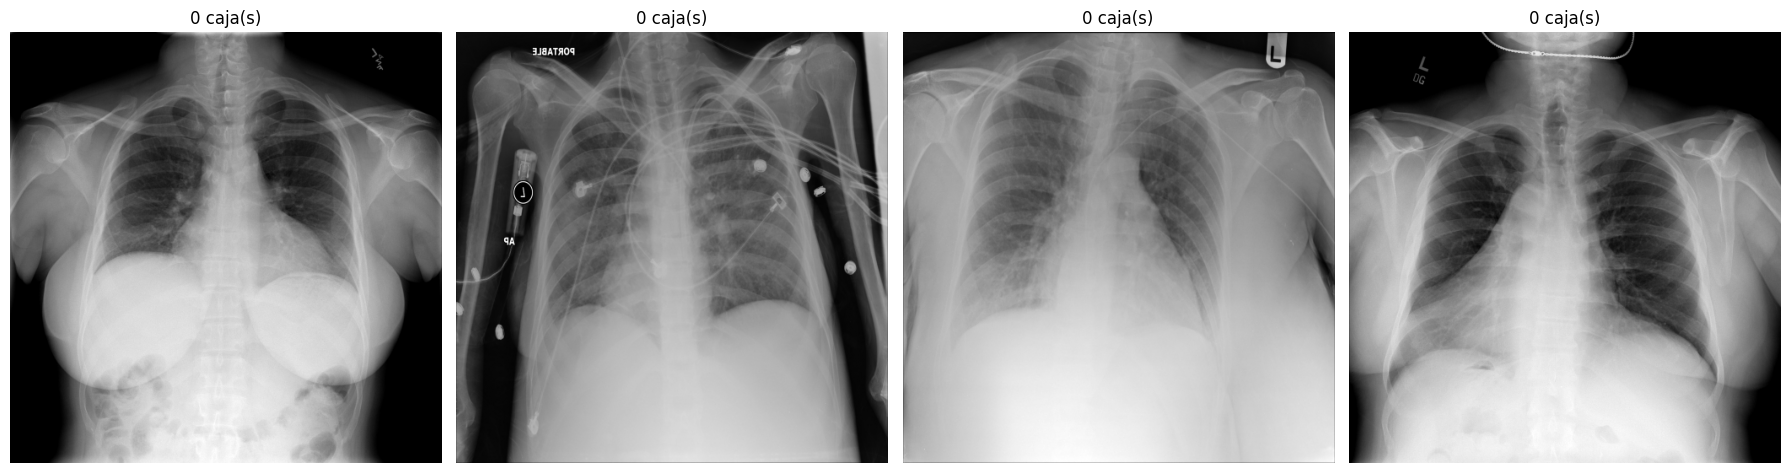

In [20]:
# %% [CELDA 18] -- Visualizar un batch con sus cajas (sanity check fundamental)
imgs_b, targets_b = next(iter(train_det_loader))
 
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, ax in enumerate(axes):
    ax.imshow(imgs_b[i][0].numpy(), cmap="gray")
    boxes = targets_b[i]["boxes"].numpy()
    for box in boxes:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
    ax.set_title(f"{len(boxes)} caja(s)")
    ax.axis("off")
plt.tight_layout()
plt.show()
# IMPORTANTE: si las cajas no caen sobre las zonas de opacidad visibles,
# hay un bug en el escalado/flip -- revisar antes de seguir.

In [21]:
# %% [CELDA 19] -- Construir el modelo RetinaNet (1 canal, 1 clase + fondo)
def build_retinanet(num_classes=2, img_size=512):  # 2 = fondo + opacidad
    # min_size/max_size = img_size para que el transform interno no
    # reescale nuestras imágenes a 800px (default pensado para COCO).
    # image_mean/image_std de 1 solo valor porque trabajamos en escala
    # de grises (1 canal), no RGB (3 canales, que es el default).
    model = retinanet_resnet50_fpn_v2(
        weights="DEFAULT",
        min_size=img_size,
        max_size=img_size,
        image_mean=[0.5],
        image_std=[0.5],
    )
 
    # Adaptar primera capa conv del backbone a 1 canal
    old_conv = model.backbone.body.conv1
    new_conv = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size,
                          stride=old_conv.stride, padding=old_conv.padding, bias=False)
    with torch.no_grad():
        new_conv.weight = nn.Parameter(old_conv.weight.mean(dim=1, keepdim=True))
    model.backbone.body.conv1 = new_conv
 
    # Reemplazar la cabeza de clasificación para que prediga num_classes
    num_anchors = model.head.classification_head.num_anchors
    in_channels = model.backbone.out_channels
    model.head.classification_head = RetinaNetClassificationHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes,
        norm_layer=partial(torch.nn.GroupNorm, 32)
    )
    return model
 
det_model = build_retinanet(num_classes=2, img_size=IMG_SIZE).to(device)
print("Modelo RetinaNet construido. Backbone conv1:", det_model.backbone.body.conv1)

Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_v2_coco-5905b1c5.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_v2_coco-5905b1c5.pth


100%|██████████| 146M/146M [00:00<00:00, 232MB/s]


Modelo RetinaNet construido. Backbone conv1: Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)


In [22]:
#%% [CELDA 19bis] -- Setup de dispositivo (1 GPU, por estabilidad)
# DECISIÓN: se descartó el split manual entre 2 GPUs con threading.
# Diagnóstico confirmado: el entrenamiento corrió de forma estable durante
# ~450 batches y luego se colgó por completo (deadlock), sin avanzar más.
# Esto coincide con un problema conocido y documentado de PyTorch: cuando
# threads de Python distintos ejecutan operaciones CUDA en GPUs distintas,
# una sincronización interna en uno puede bloquear al otro de forma no
# determinística -- por eso funcionó cientos de batches antes de fallar,
# el riesgo depende del timing exacto entre threads, no es reproducible
# de forma predecible.
# nn.DataParallel tampoco es una alternativa válida aquí porque no es
# compatible con los modelos de detección de torchvision (esperan listas
# de tensores de tamaño variable, no un batch tensorial homogéneo).
# Conclusión: se prioriza terminar de forma confiable (especialmente
# corriendo sin supervisión vía "Save & Run All") sobre la velocidad
# adicional de usar 2 GPUs. Se entrena en 1 sola GPU (cuda:0). 
devices = [device]
models_per_gpu = [det_model]
print(f"Entrenando en 1 GPU ({device}) por estabilidad -- ver nota en esta celda.")
 

Entrenando en 1 GPU (cuda) por estabilidad -- ver nota en esta celda.


In [23]:
# %% [CELDA 20] -- Optimizer y scheduler para detección (FP32 puro)
# NOTA IMPORTANTE: se descartó AMP/autocast (fp16) para este modelo.
# Diagnóstico confirmado: el Focal Loss de la cabeza de clasificación de
# RetinaNet produce NaN sistemáticamente en fp16 (problema documentado en
# la comunidad de PyTorch/torchvision -- la implementación CUDA del
# sigmoid focal loss no es estable en precisión reducida). La regresión
# de cajas (bbox_regression) sí era estable en fp16, pero el módulo de
# classification no, así que se entrena todo en FP32 por simplicidad y
# estabilidad garantizada. Se pierde algo de velocidad vs. fp16, pero se
# evita el 100% de batches descartados que se observó con autocast.
det_optimizer = torch.optim.SGD(det_model.parameters(), lr=0.005,
                                 momentum=0.9, weight_decay=1e-4)
 
# --- Warm-up + decay ---
# Se observó explosión de la loss (avg subiendo de ~0.4 a >10, con clipping
# ya activo) entrenando con lr=0.005 desde la primera iteración. Causa más
# probable: la cabeza de clasificación recién reinicializada (GroupNorm)
# no está calibrada al inicio, y un lr "normal" ahí empuja el modelo a una
# región inestable que luego el momentum (0.9) refuerza en vez de corregir.
#
# Solución estándar en RetinaNet/detectron2: warm-up lineal -- empezar con
# un lr muy bajo y subir gradualmente durante las primeras iteraciones,
# dándole tiempo al modelo de "asentarse" antes de dar pasos grandes.
WARMUP_ITERS = 200  # ~5% de una época (3781 batches/época) -- ajustable
WARMUP_START_FACTOR = 0.0001 / 0.005  # arranca en lr=0.0001, sube hasta 0.005
 
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    det_optimizer, start_factor=WARMUP_START_FACTOR, total_iters=WARMUP_ITERS
)
decay_scheduler = torch.optim.lr_scheduler.StepLR(det_optimizer, step_size=5, gamma=0.5)
# SequentialLR encadena ambos: primero warm-up (por ITERACIÓN/batch), luego
# decay (por ÉPOCA). step() se llama distinto según la fase -- ver el loop
# de entrenamiento más abajo, donde se llama warmup_scheduler.step() dentro
# del loop de batches mientras dura el warm-up.
det_scheduler = decay_scheduler  # se mantiene el nombre usado más abajo para el step por época

In [24]:
# %% [CELDA 21] -- Loop de entrenamiento de detección (1 GPU, FP32)
import time
 
LOG_PATH = "/kaggle/working/progreso_entrenamiento.txt"
 
def log_to_file(path, message, epoch_num=None):
    """Escribe una línea al log con timestamp. Se abre y cierra en cada
    llamada (modo 'a') para que el contenido quede en disco de inmediato,
    no solo en un buffer en memoria que se perdería si el kernel se cae."""
    if path is None:
        return
    timestamp = time.strftime("%Y-%m-%d %H:%M:%S")
    prefix = f"[{timestamp}]"
    if epoch_num is not None:
        prefix += f" Epoca {epoch_num}"
    with open(path, "a") as f:
        f.write(f"{prefix} {message}\n")
 
 
def train_one_epoch_det_multi_gpu(models_per_gpu, loader, optimizer, devices,
                                   log_every=10, log_path=None, epoch_num=None,
                                   warmup_scheduler=None, warmup_iters=0, global_iter=0):
    """Nombre conservado por compatibilidad con el resto del notebook, pero
    ahora entrena en 1 sola GPU (devices[0]/models_per_gpu[0]) -- ver nota
    en la celda 19bis sobre por qué se descartó el setup de 2 GPUs."""
    model = models_per_gpu[0]
    dev = devices[0]
    model.train()
    running_loss = 0.0
    n_batches = 0
    n_skipped = 0
    t_start = time.time()
    n_total_batches = len(loader)
 
    for batch_idx, (images, targets) in enumerate(loader):
        optimizer.zero_grad()
 
        images_d = [img.to(dev, non_blocking=True) for img in images]
        targets_d = [{k: v.to(dev, non_blocking=True) for k, v in t.items()} for t in targets]
 
        loss_dict = model(images_d, targets_d)
        loss = sum(loss for loss in loss_dict.values())
 
        if not torch.isfinite(loss):
            # Red de seguridad mínima; en FP32 con warm-up no debería
            # ocurrir, pero si pasa, descartamos el batch sin actualizar
            # pesos en vez de propagar un gradiente corrupto.
            n_skipped += 1
            continue
 
        loss.backward()
 
        # Gradient clipping: evita que un batch con loss anómala empuje
        # los pesos demasiado lejos de una sola vez (ver historial de
        # explosión de loss en celdas anteriores).
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
 
        optimizer.step()
        if warmup_scheduler is not None and global_iter < warmup_iters:
            warmup_scheduler.step()
 
        batch_loss = loss.item()
        running_loss += batch_loss
        n_batches += 1
        global_iter += 1
 
        if (batch_idx + 1) % log_every == 0 or (batch_idx + 1) == n_total_batches:
            elapsed = time.time() - t_start
            avg_loss_so_far = running_loss / max(n_batches, 1)
            it_per_sec = (batch_idx + 1) / elapsed
            eta_sec = (n_total_batches - (batch_idx + 1)) / max(it_per_sec, 1e-6)
            current_lr = optimizer.param_groups[0]["lr"]
            msg = (f"  batch {batch_idx+1}/{n_total_batches} | "
                   f"loss={batch_loss:.4f} (avg={avg_loss_so_far:.4f}) | lr={current_lr:.6f} | "
                   f"{elapsed:.0f}s transcurridos | ETA época: {eta_sec:.0f}s")
            print(msg)
            log_to_file(log_path, msg, epoch_num)
 
    if n_skipped > 0:
        skip_msg = f"  ({n_skipped} batches saltados por loss no finita)"
        print(skip_msg)
        log_to_file(log_path, skip_msg, epoch_num)
 
    return running_loss / max(n_batches, 1), global_iter
 
 
N_EPOCHS_DET = 5  # ajustado para caber con margen real en el presupuesto
                   # de 3-4h disponible (deadline de informe/presentación es mañana)
det_history = {"train_loss": []}
DET_LAST_CKPT_PATH = os.path.join(CHECKPOINT_DIR, "fase_b_last.pth")
DET_HISTORY_PATH = os.path.join(CHECKPOINT_DIR, "fase_b_history.json")
 
# --- Reanudación de Fase B: igual que en Fase A, si ya existe un
# checkpoint de una corrida anterior (commit cortado, error, etc.),
# retomamos desde ahí en vez de re-entrenar RetinaNet desde cero --
# esto es especialmente valioso aquí porque cada época de detección
# tarda mucho más que una de clasificación.
det_start_epoch = 0
estado_previo_b = cargar_estado_entrenamiento("fase_b")
if estado_previo_b is not None and os.path.exists(DET_LAST_CKPT_PATH):
    ckpt_b = torch.load(DET_LAST_CKPT_PATH, map_location=devices[0])
    models_per_gpu[0].load_state_dict(ckpt_b["model_state"])
    det_optimizer.load_state_dict(ckpt_b["optimizer_state"])
    if os.path.exists(DET_HISTORY_PATH):
        with open(DET_HISTORY_PATH) as f:
            det_history = json.load(f)
    det_start_epoch = estado_previo_b["ultima_epoch_completada"] + 1
    msg = f"Reanudando Fase B desde época {det_start_epoch}"
    print(msg)
    log_to_file(LOG_PATH, msg)
else:
    log_to_file(LOG_PATH, f"=== Nueva corrida iniciada -- {N_EPOCHS_DET} épocas, "
                           f"batch_size={BATCH_SIZE_DET}, 1 GPU ===")
    print(f"Log de progreso en: {LOG_PATH}")
 
fase_b_completa = det_start_epoch >= N_EPOCHS_DET
# Si reanudamos a mitad de entrenamiento, asumimos que el warm-up ya pasó
# (es razonable: el warm-up dura ~5% de la primera época, así que si ya
# completamos al menos 1 época antes de cortar, el warm-up ya terminó).
global_iter_b = WARMUP_ITERS if det_start_epoch > 0 else 0
 
for epoch in range(det_start_epoch, N_EPOCHS_DET):
    # Mismo control de presupuesto que en Fase A. Margen algo mayor (0.7h)
    # porque cada época de detección es más larga, así que si quedan menos
    # de 0.7h conviene no arriesgarse a empezar otra época que no se
    # alcance a completar ni a guardar de forma segura.
    if tiempo_agotado(margen_horas=0.5):  # con 5 épocas hay más colchón real;
                                            # margen algo más prudente que antes
        msg = (f"⏱️ Presupuesto de tiempo agotado ({horas_transcurridas():.1f}h transcurridas) "
               f"-- deteniendo Fase B en época {epoch} de forma segura.")
        print(msg)
        log_to_file(LOG_PATH, msg)
        break
 
    try:
        epoch_start = time.time()
        train_loss, global_iter_b = train_one_epoch_det_multi_gpu(
            models_per_gpu, train_det_loader, det_optimizer, devices,
            log_path=LOG_PATH, epoch_num=epoch + 1,
            warmup_scheduler=warmup_scheduler, warmup_iters=WARMUP_ITERS,
            global_iter=global_iter_b
        )
        det_scheduler.step()
        det_history["train_loss"].append(train_loss)
        epoch_elapsed = time.time() - epoch_start
 
        epoch_msg = (f"FIN ÉPOCA {epoch+1}/{N_EPOCHS_DET} | train_loss={train_loss:.4f} | "
                     f"duración={epoch_elapsed:.0f}s | sesión={horas_transcurridas():.2f}h")
        print(epoch_msg)
        log_to_file(LOG_PATH, epoch_msg)
 
        torch.save(det_model.state_dict(), f"retinanet_epoch{epoch+1}.pth")
 
        # Checkpoint de reanudación: pesos + optimizer, sobreescrito cada
        # época (no acumulamos uno por época para no llenar el disco --
        # los retinanet_epoch{N}.pth de arriba sí quedan todos, por si
        # quieres comparar entre épocas más adelante).
        torch.save({
            "model_state": models_per_gpu[0].state_dict(),
            "optimizer_state": det_optimizer.state_dict(),
        }, DET_LAST_CKPT_PATH)
        with open(DET_HISTORY_PATH, "w") as f:
            json.dump(det_history, f)
        guardar_estado_entrenamiento("fase_b", epoch)
 
        if epoch == N_EPOCHS_DET - 1:
            fase_b_completa = True
 
    except Exception as e:
        err_msg = f"❌ ERROR en época {epoch+1} de Fase B: {type(e).__name__}: {e}"
        print(err_msg)
        log_to_file(LOG_PATH, err_msg)
        break
 
print(f"\nFase B {'COMPLETA' if fase_b_completa else 'DETENIDA (parcial)'} | "
      f"tiempo de sesión usado: {horas_transcurridas():.2f}h")
 
# Nota: para mantener este baseline simple no implementamos aquí el cálculo
# de mAP en validación durante el loop (es más código). Lo añadimos aparte
# en la celda 23 con un cálculo simplificado, para no añadir complejidad
# innecesaria a un primer baseline. Si quieres mAP por época, lo agregamos
# en la siguiente iteración del notebook.
 

Log de progreso en: /kaggle/working/progreso_entrenamiento.txt
  batch 10/3781 | loss=1.0794 (avg=0.5472) | lr=0.000345 | 6s transcurridos | ETA época: 2400s
  batch 20/3781 | loss=0.2959 (avg=0.4313) | lr=0.000590 | 12s transcurridos | ETA época: 2245s
  batch 30/3781 | loss=0.2910 (avg=0.4215) | lr=0.000835 | 18s transcurridos | ETA época: 2207s
  batch 40/3781 | loss=0.5394 (avg=0.4405) | lr=0.001080 | 24s transcurridos | ETA época: 2203s
  batch 50/3781 | loss=0.0336 (avg=0.4255) | lr=0.001325 | 30s transcurridos | ETA época: 2205s
  batch 60/3781 | loss=0.0323 (avg=0.4265) | lr=0.001570 | 36s transcurridos | ETA época: 2203s
  batch 70/3781 | loss=0.7909 (avg=0.4081) | lr=0.001815 | 41s transcurridos | ETA época: 2191s
  batch 80/3781 | loss=0.5088 (avg=0.3956) | lr=0.002060 | 47s transcurridos | ETA época: 2174s
  batch 90/3781 | loss=0.2425 (avg=0.3797) | lr=0.002305 | 53s transcurridos | ETA época: 2155s
  batch 100/3781 | loss=0.4449 (avg=0.3736) | lr=0.002550 | 58s transcurri

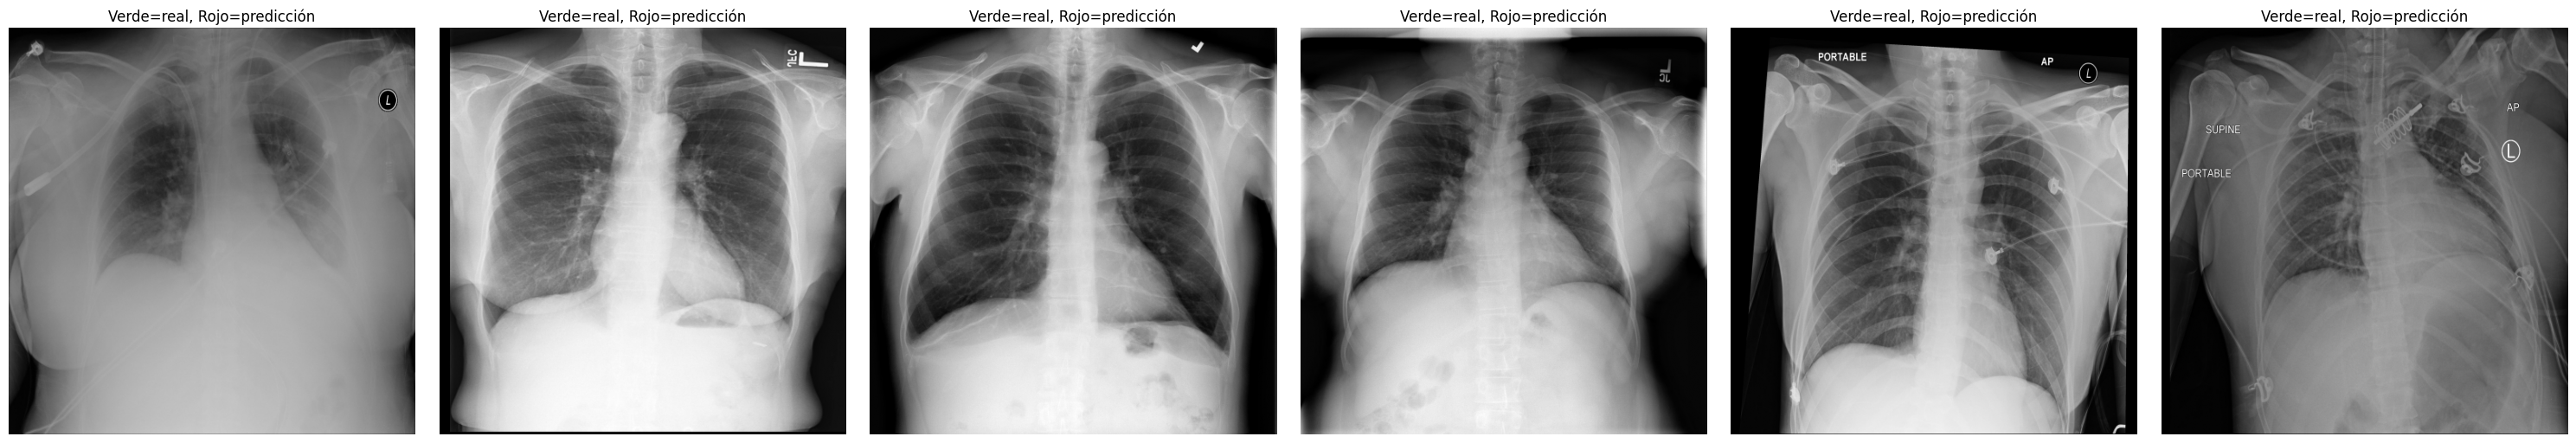

In [25]:
# %% [CELDA 22] -- Inferencia: generar predicciones sobre el set de validación
def predict_boxes(model, images, device, score_threshold=0.3):
    model.eval()
    images = [img.to(device) for img in images]
    with torch.no_grad():
        outputs = model(images)
    results = []
    for out in outputs:
        keep = out["scores"] > score_threshold
        boxes = out["boxes"][keep].cpu().numpy()
        scores = out["scores"][keep].cpu().numpy()
        results.append((boxes, scores))
    return results
 
# Visualizar predicciones vs ground truth en un batch de validación
val_imgs_b, val_targets_b = next(iter(val_det_loader))
preds = predict_boxes(det_model, val_imgs_b, device, score_threshold=0.3)
 
fig, axes = plt.subplots(1, len(val_imgs_b), figsize=(5 * len(val_imgs_b), 5))
if len(val_imgs_b) == 1:
    axes = [axes]
 
for i, ax in enumerate(axes):
    ax.imshow(val_imgs_b[i][0].numpy(), cmap="gray")
 
    # Ground truth en verde
    for box in val_targets_b[i]["boxes"].numpy():
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
 
    # Predicciones en rojo
    boxes_pred, scores_pred = preds[i]
    for box, score in zip(boxes_pred, scores_pred):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"{score:.2f}", color="red", fontsize=9)
 
    ax.set_title("Verde=real, Rojo=predicción")
    ax.axis("off")
 
plt.tight_layout()
plt.show()


In [26]:
# %% [CELDA 23] -- Generar submission.csv en el formato requerido por Kaggle
# Formato esperado: patientId,PredictionString
# PredictionString: "confidence x y width height confidence x y width height ..."
# (vacío si no se predice neumonía)
 
TEST_IMG_DIR = os.path.join(INPUT_DIR, "stage_2_test_images")
sample_sub = pd.read_csv(os.path.join(INPUT_DIR, "stage_2_sample_submission.csv"))
 
class RSNATestDataset(Dataset):
    def __init__(self, patient_ids, img_dir, img_size=512):
        self.patient_ids = patient_ids
        self.img_dir = img_dir
        self.img_size = img_size
        self.orig_size = 1024
 
    def __len__(self):
        return len(self.patient_ids)
 
    def __getitem__(self, idx):
        patient_id = self.patient_ids[idx]
        path = os.path.join(self.img_dir, f"{patient_id}.dcm")
        dcm = pydicom.dcmread(path)
        img = dcm.pixel_array.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-7)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        return img_tensor, patient_id
 
 
test_dataset = RSNATestDataset(sample_sub["patientId"].tolist(), TEST_IMG_DIR, IMG_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE_DET, shuffle=False,
                          collate_fn=lambda b: (list(zip(*b))[0], list(zip(*b))[1]))
 
SCORE_THRESHOLD = 0.3  # umbral de confianza -- ajustar tras inspección visual
SCALE_BACK = 1024 / IMG_SIZE  # volver a la escala original 1024x1024
 
results = []
det_model.eval()
 
with torch.no_grad():
    for images, patient_ids in test_loader:
        images = [img.to(device) for img in images]
        outputs = det_model(images)
 
        for patient_id, out in zip(patient_ids, outputs):
            keep = out["scores"] > SCORE_THRESHOLD
            boxes = out["boxes"][keep].cpu().numpy()
            scores = out["scores"][keep].cpu().numpy()
 
            if len(boxes) == 0:
                pred_string = ""
            else:
                parts = []
                for (x1, y1, x2, y2), score in zip(boxes, scores):
                    # volver a escala 1024 y a formato x,y,w,h
                    x1o, y1o, x2o, y2o = x1 * SCALE_BACK, y1 * SCALE_BACK, x2 * SCALE_BACK, y2 * SCALE_BACK
                    w, h = x2o - x1o, y2o - y1o
                    parts.append(f"{score:.4f} {x1o:.1f} {y1o:.1f} {w:.1f} {h:.1f}")
                pred_string = " ".join(parts)
 
            results.append({"patientId": patient_id, "PredictionString": pred_string})
 
submission_df = pd.DataFrame(results)
submission_df.to_csv("submission.csv", index=False)
print(submission_df.head(10))
print(f"\nTotal filas: {len(submission_df)}")
print(f"Filas con predicción vacía: {(submission_df['PredictionString'] == '').sum()}")


                              patientId PredictionString
0  0000a175-0e68-4ca4-b1af-167204a7e0bc                 
1  0005d3cc-3c3f-40b9-93c3-46231c3eb813                 
2  000686d7-f4fc-448d-97a0-44fa9c5d3aa6                 
3  000e3a7d-c0ca-4349-bb26-5af2d8993c3d                 
4  00100a24-854d-423d-a092-edcf6179e061                 
5  0015597f-2d69-4bc7-b642-5b5e01534676                 
6  001b0c51-c7b3-45c1-9c17-fa7594cab96e                 
7  0022bb50-bf6c-4185-843e-403a9cc1ea80                 
8  00271e8e-aea8-4f0a-8a34-3025831f1079                 
9  0028450f-5b8e-4695-9416-8340b6f686b0                 

Total filas: 3000
Filas con predicción vacía: 2910


%% [CELDA 24] -- Conclusiones de la Fase B y próximos pasos
"""
CHECKLIST de este baseline de detección:
 
[ ] ¿Las cajas predichas en la celda 22 caen razonablemente sobre las cajas reales?
[ ] ¿El submission.csv tiene el formato correcto? (revisar contra
    stage_2_sample_submission.csv)
[ ] ¿Cuántas imágenes de test reciben 0 predicciones? ¿Coincide aproximadamente
    con el ~77.5% de negativos que viste en el EDA?
 
ESTE ES UN BASELINE, no la versión optimizada. Mejoras conocidas para
la siguiente iteración (basadas en las soluciones top de la competencia):
 
1. Ajustar SCORE_THRESHOLD sistemáticamente (probar varios valores y medir
   impacto, no solo 0.3 a ojo).
2. Encoger ligeramente las cajas predichas (~10-17%) -- los ganadores
   notaron que las cajas de test tienden a ser más pequeñas que las de train.
3. Entrenar más épocas / con más cómputo, y usar mixed precision (AMP)
   para acelerar.
4. Ensemble de 2+ modelos (distintos backbones o seeds) con weighted box fusion.
5. Implementar el cálculo de mAP real (con múltiples umbrales IoU) en
   validación, para comparar configuraciones sin depender solo del leaderboard.
6. Curriculum: empezar entrenando solo con imágenes positivas unas épocas,
   luego añadir negativas (ayuda con el desbalance fuerte).
 
Siguiente paso sugerido: implementar el cálculo de mAP local (función de
evaluación oficial) para poder comparar experimentos sin gastar submissions.
"""

In [27]:
# %% [CELDA 25] -- Resumen final de la corrida (para revisar de un vistazo al volver)
print("=" * 70)
print("RESUMEN FINAL DE LA CORRIDA")
print("=" * 70)
print(f"Tiempo total de sesión usado: {horas_transcurridas():.2f}h de {MAX_SESSION_HOURS}h presupuestadas")
print()
print(f"FASE A (clasificación): {'✅ COMPLETA' if fase_a_completa else '⚠️ PARCIAL/INCOMPLETA'}")
print(f"  - Mejor AUC de validación: {best_auc:.4f}")
print(f"  - Épocas completadas: {len(history['train_loss'])}/{N_EPOCHS}")
print()
print(f"FASE B (detección RetinaNet): {'✅ COMPLETA' if fase_b_completa else '⚠️ PARCIAL/INCOMPLETA'}")
print(f"  - Épocas completadas: {len(det_history['train_loss'])}/{N_EPOCHS_DET}")
if len(det_history["train_loss"]) > 0:
    print(f"  - Última train_loss: {det_history['train_loss'][-1]:.4f}")
print(f"  - submission.csv generado: {'sí' if os.path.exists('submission.csv') else 'no'}")
print()
if not fase_a_completa or not fase_b_completa:
    print("⚠️ Alguna fase quedó incompleta. Para continuar, vuelve a correr este")
    print("   mismo notebook (Save & Run All de nuevo) -- retomará automáticamente")
    print("   desde el último checkpoint guardado en /kaggle/working/checkpoints/")
print("=" * 70)

RESUMEN FINAL DE LA CORRIDA
Tiempo total de sesión usado: 3.35h de 11.0h presupuestadas

FASE A (clasificación): ✅ COMPLETA
  - Mejor AUC de validación: 0.8685
  - Épocas completadas: 10/10

FASE B (detección RetinaNet): ✅ COMPLETA
  - Épocas completadas: 5/5
  - Última train_loss: 0.2136
  - submission.csv generado: sí

